# Ablation study — results across propositions

Reads `out/<mode>/<label>/<run_id>/result.txt` and plots per-proposition **averages** across
every run, for the two arms (`mymethod` vs `ablated`).

- Set `MODEL` below (only `opus` for now — it selects run folders by the `_<MODEL>` label suffix).
- Every run of a prop is reflected: the **outcome breakdown** counts SUCCESS / GAVEUP / FAIL /
  RUNNING per prop (RUNNING = crashed/incomplete run, cost 0 — excluded from the numeric averages
  but still shown so no run is hidden).
- Numeric averages (cost, wall time, compile time) are over *finished* runs only.
- **Compile time is informal** — runs land on different CPUs, so treat it as a rough signal.

**Kernel:** use a Python with pandas + matplotlib — e.g. `~/.venvs/leaneuclid/bin/python`.

In [1]:
# ---- config ----------------------------------------------------------------
MODEL    = "opus"   # only opus for now; selects run folders whose label ends _<MODEL>
OUT_BASE = "/h/56/taddmao/code/autoform/DNA/reproducable_experiments/ablation_study/out"

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTCOMES     = ["SUCCESS", "GAVEUP", "FAIL", "RUNNING"]   # RUNNING = crashed/incomplete
OUTCOME_COL  = {"SUCCESS": "#2ca02c", "GAVEUP": "#ff7f0e", "FAIL": "#d62728", "RUNNING": "#9e9e9e"}
MODE_COL     = {"mymethod": "#1f77b4", "ablated": "#ff7f0e"}
FINISHED     = ["SUCCESS", "GAVEUP", "FAIL"]              # have real cost/wall/compile numbers

In [2]:
# ---- load every result.txt into one tidy DataFrame -------------------------
def load_results(out_base, model):
    rows = []
    for path in glob.glob(os.path.join(out_base, "*", f"*_{model}", "*", "result.txt")):
        d = {}
        for line in open(path):
            k, sep, v = line.partition(":")
            if sep:
                d[k.strip()] = v.strip()
        d["run_id"] = os.path.basename(os.path.dirname(path))
        rows.append(d)
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    bp = df["prop"].str.extract(r"Book(?P<book>\d+)/Prop(?P<propnum>\d+)")
    df["book"]       = bp["book"].astype(int)
    df["propnum"]    = bp["propnum"].astype(int)
    df["prop_label"] = "B" + df["book"].astype(str) + ".P" + df["propnum"].astype(str)
    for c in ["cost_usd", "wall_sec", "compile_sec"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")     # "<pending>" -> NaN
    df["wall_min"]  = df["wall_sec"] / 60.0
    df["result"]    = df["result"].str.upper()
    df["finished"]  = df["result"].isin(FINISHED)
    return df.sort_values(["book", "propnum", "mode", "run_id"]).reset_index(drop=True)

df = load_results(OUT_BASE, MODEL)
print(f"{len(df)} runs loaded for MODEL={MODEL!r}"
      + ("" if df.empty else f" | modes={sorted(df['mode'].unique())} | "
                             f"props={sorted(df['prop_label'].unique())}"))
df[["mode", "prop", "run_id", "result", "stop_reason", "cost_usd", "wall_sec", "compile_sec"]] \
    if not df.empty else df

27 runs loaded for MODEL='opus' | modes=['ablated', 'mymethod'] | props=['B1.P12', 'B1.P18', 'B1.P20', 'B1.P27', 'B1.P3', 'B1.P30', 'B1.P36', 'B1.P45', 'B1.P47', 'B1.P6']


,mode,prop,run_id,result,stop_reason,cost_usd,wall_sec,compile_sec
0,ablated,Book1/Prop03,20260719-193910-fab15842,SUCCESS,done,1.59686,250.346,3.0
1,ablated,Book1/Prop03,20260719-194334-95d75e25,SUCCESS,done,1.37590,209.123,2.0
2,ablated,Book1/Prop03,20260719-194714-c7332038,SUCCESS,done,1.32310,206.638,3.0
3,ablated,Book1/Prop06,20260719-193910-deed27fd,SUCCESS,done,4.71706,762.473,3.0
4,ablated,Book1/Prop06,20260719-195213-a92accb8,SUCCESS,done,4.91380,1610.060,2.0
5,ablated,Book1/Prop06,20260720-012015-419d0e98,SUCCESS,done,3.31021,860.491,2.0
6,ablated,Book1/Prop12,20260719-193910-80d83b18,SUCCESS,done,3.34758,581.144,3.0
7,ablated,Book1/Prop12,20260719-194927-a2ebf3b2,SUCCESS,done,3.41628,687.707,2.0
8,ablated,Book1/Prop12,20260719-200109-fdab2876,SUCCESS,done,5.57722,1526.060,6.0
9,ablated,Book1/Prop18,20260719-193910-05682b81,SUCCESS,done,4.31428,931.648,2.0


In [3]:
# ---- aggregate per (mode, prop): outcome counts + averages over finished runs
def aggregate(df):
    recs = []
    for (mode, book, propnum, label), x in df.groupby(["mode", "book", "propnum", "prop_label"]):
        fin = x[x["finished"]]
        recs.append(dict(
            mode=mode, book=book, propnum=propnum, prop_label=label,
            n_runs=len(x),
            n_success=int((x["result"] == "SUCCESS").sum()),
            n_gaveup =int((x["result"] == "GAVEUP").sum()),
            n_fail   =int((x["result"] == "FAIL").sum()),
            n_running=int((x["result"] == "RUNNING").sum()),
            success_rate=float((x["result"] == "SUCCESS").mean()),
            mean_cost_usd   =float(fin["cost_usd"].mean())    if len(fin) else np.nan,
            mean_wall_min   =float(fin["wall_min"].mean())    if len(fin) else np.nan,
            mean_compile_sec=float(fin["compile_sec"].mean()) if len(fin) else np.nan,
        ))
    return pd.DataFrame(recs).sort_values(["book", "propnum", "mode"]).reset_index(drop=True)

agg = aggregate(df) if not df.empty else pd.DataFrame()
agg

,mode,book,propnum,prop_label,n_runs,n_success,n_gaveup,n_fail,n_running,success_rate,mean_cost_usd,mean_wall_min,mean_compile_sec
0,ablated,1,3,B1.P3,3,3,0,0,0,1.0,1.431953,3.700594,2.666667
1,ablated,1,6,B1.P6,3,3,0,0,0,1.0,4.313690,17.961244,2.333333
2,ablated,1,12,B1.P12,3,3,0,0,0,1.0,4.113693,15.527283,3.666667
3,ablated,1,18,B1.P18,2,2,0,0,0,1.0,3.467920,11.654792,2.500000
4,ablated,1,20,B1.P20,1,0,0,0,0,0.0,NaN,NaN,NaN
5,mymethod,1,20,B1.P20,3,3,0,0,0,1.0,15.264133,46.924111,4.333333
6,ablated,1,27,B1.P27,1,1,0,0,0,1.0,8.490900,43.207833,2.000000
7,ablated,1,30,B1.P30,1,0,0,0,0,0.0,NaN,NaN,NaN
8,mymethod,1,30,B1.P30,3,3,0,0,0,1.0,23.075143,46.535222,2.333333
9,ablated,1,36,B1.P36,1,0,0,0,0,0.0,NaN,NaN,NaN


In [4]:
# ---- plotting helpers ------------------------------------------------------
def prop_order(agg):
    return (agg[["book", "propnum", "prop_label"]].drop_duplicates()
            .sort_values(["book", "propnum"])["prop_label"].tolist())

def grouped_bar(agg, metric, title, ylabel, note=None):
    """One bar per mode, grouped by prop."""
    props = prop_order(agg); modes = sorted(agg["mode"].unique())
    x = np.arange(len(props)); w = 0.8 / max(1, len(modes))
    fig, ax = plt.subplots(figsize=(max(6, 1.1 * len(props) + 2), 4))
    for i, m in enumerate(modes):
        sub = agg[agg["mode"] == m].set_index("prop_label").reindex(props)
        ax.bar(x + i * w - 0.4 + w / 2, sub[metric].to_numpy(dtype=float), w,
               label=m, color=MODE_COL.get(m))
    ax.set_xticks(x); ax.set_xticklabels(props); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(title="arm"); ax.grid(axis="y", alpha=0.3)
    if note:
        fig.text(0.01, 0.005, note, fontsize=8, color="gray")
    plt.tight_layout(); plt.show()

## Outcomes per proposition\nEvery run is counted — SUCCESS / GAVEUP / FAIL / RUNNING.

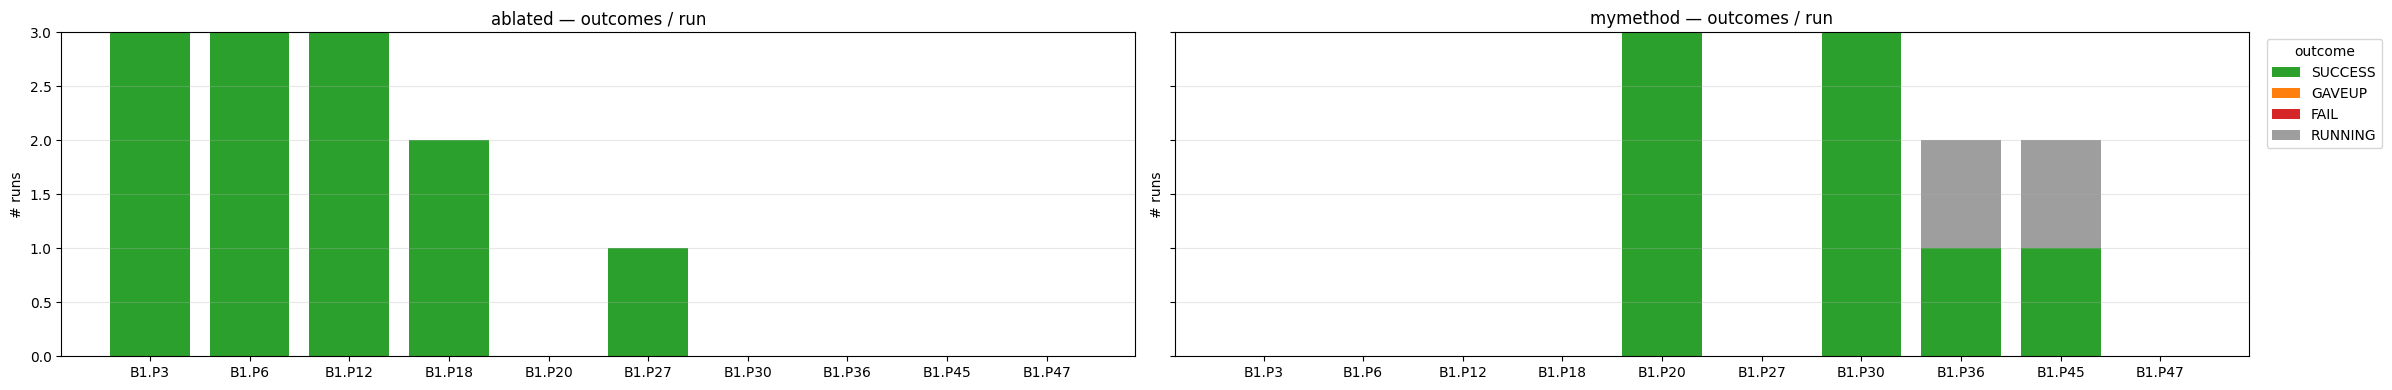

In [5]:
# ---- outcomes per prop (EVERY run reflected) -------------------------------
# One subplot per arm; stacked bars count each outcome per prop.
if not df.empty:
    props = prop_order(agg); modes = sorted(agg["mode"].unique())
    x = np.arange(len(props))
    fig, axes = plt.subplots(1, len(modes), figsize=(max(5, 1.1 * len(props) + 1) * len(modes), 4),
                             sharey=True, squeeze=False)
    for ax, m in zip(axes[0], modes):
        sub = agg[agg["mode"] == m].set_index("prop_label").reindex(props).fillna(0)
        bottom = np.zeros(len(props))
        for oc in OUTCOMES:
            vals = sub[f"n_{oc.lower()}"].to_numpy(dtype=float)
            ax.bar(x, vals, bottom=bottom, label=oc, color=OUTCOME_COL[oc])
            bottom += vals
        ax.set_xticks(x); ax.set_xticklabels(props); ax.set_title(f"{m} — outcomes / run")
        ax.set_ylabel("# runs"); ax.grid(axis="y", alpha=0.3)
    axes[0][-1].legend(title="outcome", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(); plt.show()

## Averages per proposition

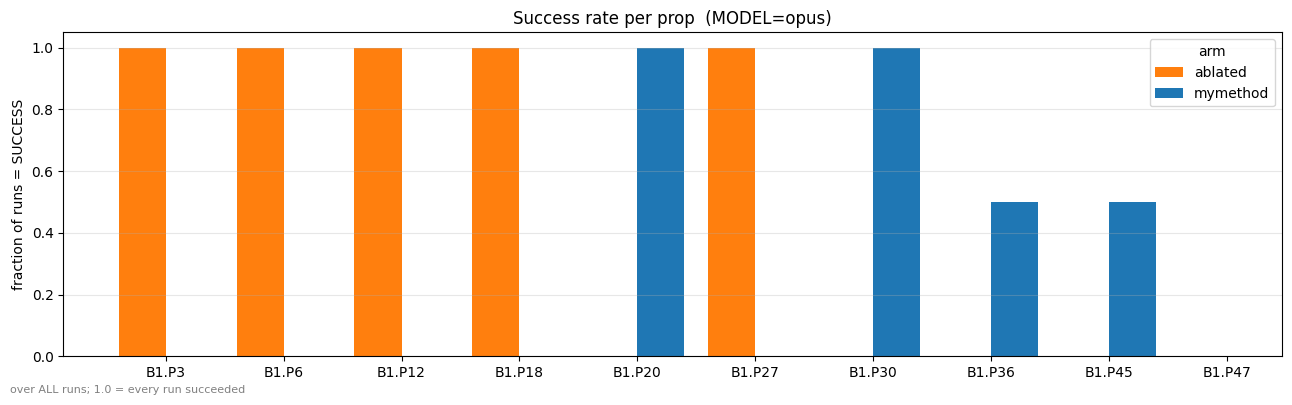

In [6]:
# ---- success rate per prop (fraction of runs that succeeded) ----------------
if not df.empty:
    grouped_bar(agg, "success_rate", f"Success rate per prop  (MODEL={MODEL})",
                "fraction of runs = SUCCESS",
                note="over ALL runs; 1.0 = every run succeeded")

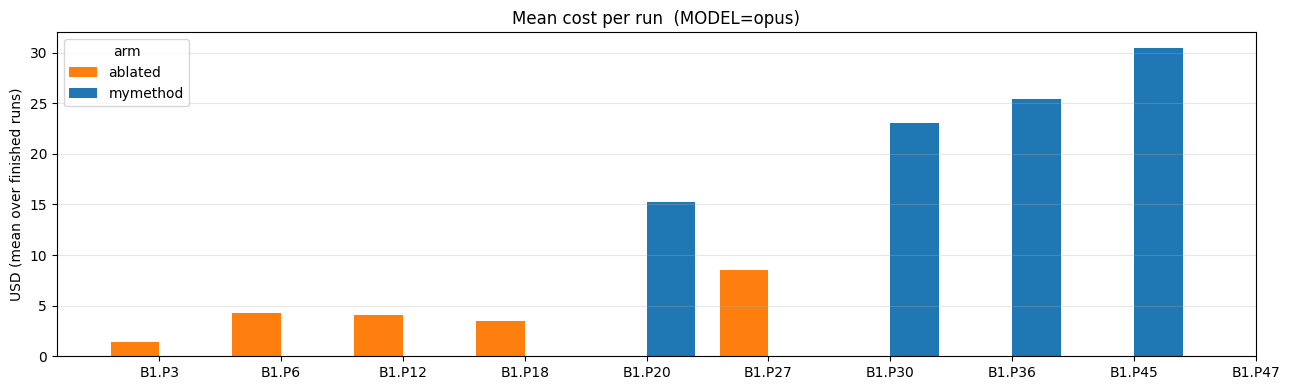

In [7]:
# ---- average cost per prop -------------------------------------------------
if not df.empty:
    grouped_bar(agg, "mean_cost_usd", f"Mean cost per run  (MODEL={MODEL})",
                "USD (mean over finished runs)")

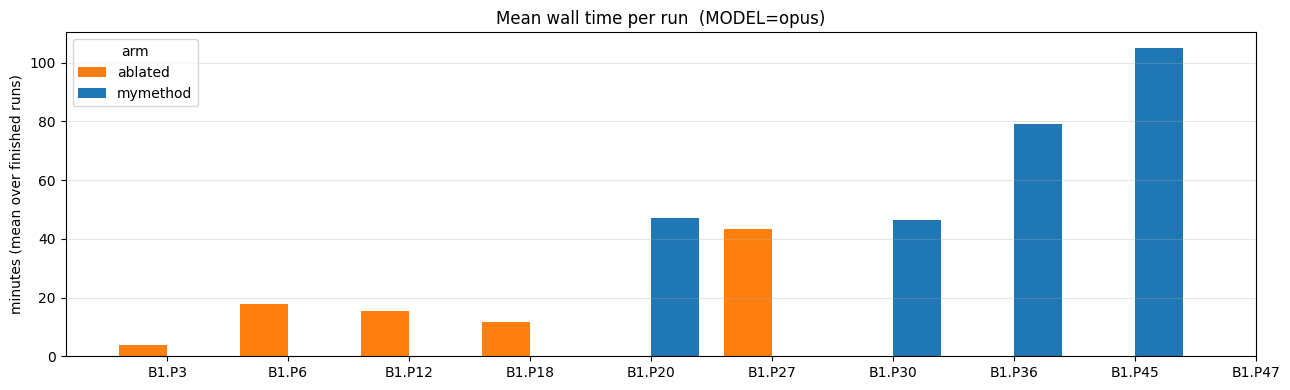

In [8]:
# ---- average wall time per prop --------------------------------------------
if not df.empty:
    grouped_bar(agg, "mean_wall_min", f"Mean wall time per run  (MODEL={MODEL})",
                "minutes (mean over finished runs)")

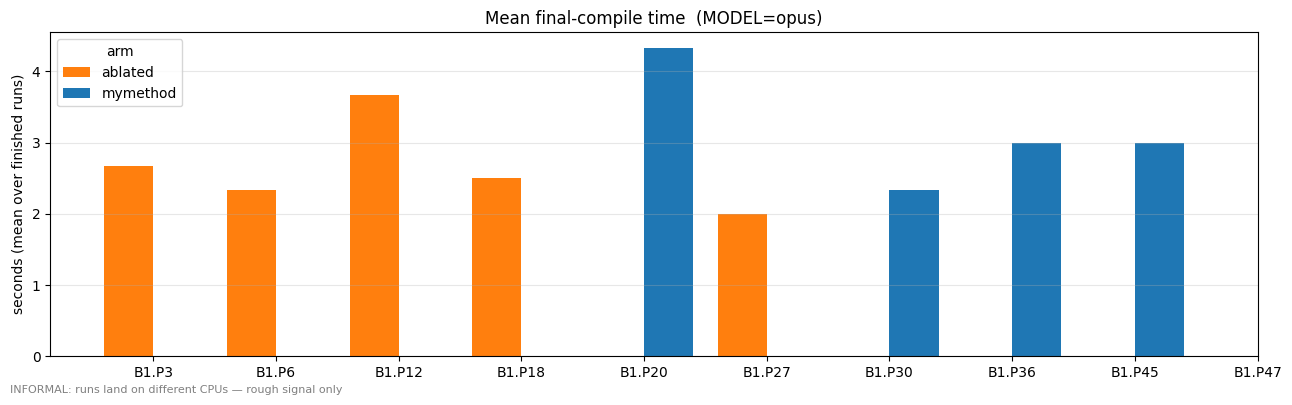

In [9]:
# ---- average compile time per prop (INFORMAL — different CPUs) --------------
if not df.empty:
    grouped_bar(agg, "mean_compile_sec", f"Mean final-compile time  (MODEL={MODEL})",
                "seconds (mean over finished runs)",
                note="INFORMAL: runs land on different CPUs — rough signal only")